USING LTSM
-

- Tokenization + NN
    - EMBEDDING --> FLATTEN --> DENSE

- RNN(LTSM)
    - EMBEDDING --> LTSM --> DENSE

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
df = pd.read_csv("../data/spam_mail.csv")
print(f"Shape : {df.shape}\n{'--'*69}\nNull\n{df.isna().sum()}")

Shape : (5572, 2)
------------------------------------------------------------------------------------------------------------------------------------------
Null
Category    0
Masseges    0
dtype: int64


In [93]:
df.head(3)

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [94]:
df.rename(columns={"Category":'category',"Masseges":'messages'},inplace=True)

In [95]:
df.head(3)

,category,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


TRAIN TEST SPLIT

In [96]:
from sklearn.model_selection import train_test_split
x = df['messages']
y = df['category']

y = y.map({"ham":0, "spam":1})

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state = 42,
    test_size = 0.2,
    stratify = y
)

print(f"x_train Shape: {x_train.shape}\ny_train.shape {y_train.shape}")
print(f"x_train Shape: {x_test.shape}\ny_train.shape {y_test.shape}")

x_train Shape: (4457,)
y_train.shape (4457,)
x_train Shape: (1115,)
y_train.shape (1115,)


TOKENIZATION is DEPRECATED
-


- Therefore we use TextVectorization

<span style="color:pink">text --> tokenizer --> sequence --> model(embedding,LSTM and all)</span>


Compared to Tokenizer:
-
- Tokenizer |------------------| TextVectorization
- external preprocessing |-----| built into model
- manual steps |--------------| integrated pipeline
- legacy |---------------------| modern
- less flexible	|---------------| more flexible

DEPRECATED
--

In [97]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [98]:
vocab_words = 5000 # choose top 5000 words only
tokenizer = Tokenizer(num_words = vocab_words, oov_token = "<OOV>", )
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

max_length = 50
x_train_pad = pad_sequences(x_train_seq, maxlen = max_length, padding = 'post')

WORKING
--

<span style="color:pink">text → TextVectorization → model</span>

In [99]:
from tensorflow.keras.layers import TextVectorization

In [109]:
vectorizer = TextVectorization(
    max_tokens = vocab_words,
    output_sequence_length=50, # this one do padding to the sequence
    standardize = None
) 

# adapt = learn vocabulary
vectorizer.adapt(x_train)

TRAINING MODEL
--

In [101]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [117]:
lstm = Sequential([
    vectorizer,
    Embedding(input_dim = vocab_words, output_dim = 32, mask_zero=True),
    LSTM(64),
    Dense(1,activation = 'sigmoid',)
])

In [118]:
lstm.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [104]:
x_train = x_train.values
y_train = y_train.values

x_test = x_test.values
y_test = y_test.values



Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8658 - loss: 0.4134
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8658 - loss: 0.3972
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8658 - loss: 0.3950
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8658 - loss: 0.3956
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8658 - loss: 0.3954
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8658 - loss: 0.3956
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8658 - loss: 0.3957
Epoch 8/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8658 - loss: 0.3951


In [119]:
lstm.fit(
    x_train,
    y_train,
    epochs = 5,
    batch_size  = 32
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9053 - loss: 0.3034
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9834 - loss: 0.0625
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9908 - loss: 0.0349
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9955 - loss: 0.0202
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9969 - loss: 0.0115


In [120]:
lstm_pred = lstm.predict(x_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [137]:
lstm_pred_threshold = (lstm_pred >= 0.3).astype(int)

In [138]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix

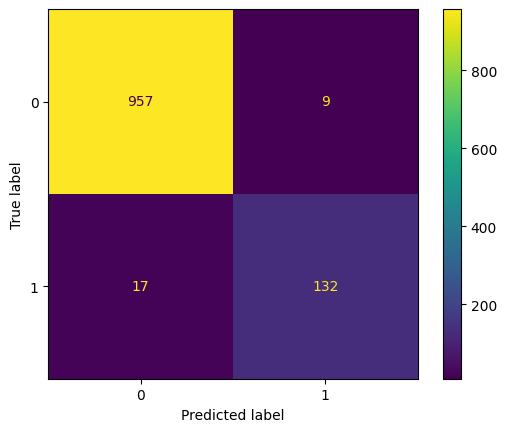

In [139]:
lstm_cm = confusion_matrix(y_test,lstm_pred_threshold) 
disp = ConfusionMatrixDisplay(lstm_cm)
disp.plot()
plt.show()